# PyTorch 회귀분석 개선 실험: 당뇨병 진행도 예측 (ver.1)

---

## 개선 동기 (Motivation)

**기존 모델(ver1)의 최종 성능:**

| 지표 | 기존 값 | 해석 |
|------|---------|------|
| RMSE | 53.98 | 예측 오차의 평균 크기 |
| R²   | 0.45  | 분산의 45%만 설명 → 설명력 부족 |

<br>

---

**진단 전제:** 개선 방향을 결정하기 전에 반드시 아래 두 가지를 먼저 확인해야 한다.


1. **과적합(Overfitting) vs 과소적합(Underfitting)?**
   - Train Loss ≫ Val Loss → 과소적합 → 모델 용량(capacity) 확장 필요
   - Val Loss ≫ Train Loss → 과적합  → 정규화(regularization) 필요
   - Val Loss가 조기에 발산 → Early Stopping 필요

2. **Val Loss 최솟값 에포크가 500보다 훨씬 작은가?**
   - 그렇다면: 이미 수렴 이후에도 불필요하게 학습이 지속됨 → Early Stopping 도입

<br>

---

## 개선 전략 도출 (Step-by-step)

```
Step 1. 과적합 진단  →  Dropout + Weight Decay (L2 정규화)
Step 2. 수렴 효율화 →  Batch Normalization + LR Scheduler
Step 3. 조기 종료   →  Early Stopping (Val Loss patience 기반)
Step 4. 종합 실험   →  위 3가지를 결합한 최종 모델 비교
```

**가정:**
- 데이터 증강(Data Augmentation)은 표 형식 데이터에 적용하지 않는다.
- Feature Engineering(교호항, 다항 피처)은 이 실습의 범위 밖이다.
- 모든 실험은 동일한 Train/Val/Test 분할 및 SEED=42를 사용한다.



---


## 0. 공통 설정: 라이브러리, 시드, 데이터

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


# ── 재현성 설정 ───────────────────────────────────────────────────────────────
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[Device] {device}")

[Device] cuda


In [2]:
# ── 데이터 로드 및 분할 (기존과 동일: 재현성 보장) ─────────────────────────────
dataset = load_diabetes()
x, y = dataset.data, dataset.target

x_tv, x_test, y_tv, y_test = train_test_split(x, y, test_size=0.2, random_state=SEED)
x_train, x_val, y_train, y_val = train_test_split(x_tv, y_tv, test_size=0.2, random_state=SEED)

print(f"Train: {len(x_train)} | Val: {len(x_val)} | Test: {len(x_test)}")


# ── Tensor 변환 유틸리티 ──────────────────────────────────────────────────────
def to_tensor_pair(x_arr, y_arr):
    """NumPy 배열 쌍을 float32 Tensor로 변환한다. y는 (N,1) shape."""
    xt = torch.tensor(x_arr, dtype=torch.float32)
    yt = torch.tensor(y_arr, dtype=torch.float32).reshape(-1, 1)
    return xt, yt

x_train_t, y_train_t = to_tensor_pair(x_train, y_train)
x_val_t,   y_val_t   = to_tensor_pair(x_val,   y_val)
x_test_t,  y_test_t  = to_tensor_pair(x_test,  y_test)

BATCH_SIZE = 64

def make_loader(x_t, y_t, shuffle: bool) -> DataLoader:
    return DataLoader(TensorDataset(x_t, y_t), batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = make_loader(x_train_t, y_train_t, shuffle=True)
val_loader   = make_loader(x_val_t,   y_val_t,   shuffle=False)

Train: 282 | Val: 71 | Test: 89




---


## 공통 유틸리티: 학습 루프 및 평가 함수

모든 실험에서 재사용 가능한 모듈로 분리한다.
단, Early Stopping 유무를 `patience` 파라미터로 제어한다.

In [3]:
def train_one_epoch(model, loader, criterion, optimizer):
    """1 에포크 학습. 배치 평균 MSE Loss를 반환한다."""
    model.train()
    total = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / len(loader)


def evaluate(model, loader, criterion):
    """검증/테스트 손실 계산. 가중치 갱신 없음."""
    model.eval()
    total = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            total += criterion(model(xb), yb).item()
    return total / len(loader)


def run_experiment(model, optimizer, criterion, scheduler=None,
                   num_epochs=500, patience=None, verbose=True):
    """
    학습 루프 실행기. Early Stopping과 LR Scheduler를 옵션으로 지원한다.

    Args:
        scheduler : torch.optim.lr_scheduler 객체 (없으면 None)
        patience  : Early Stopping 대기 에포크 수 (None이면 비활성화)

    Returns:
        (train_losses, val_losses, best_epoch)
    """
    train_losses, val_losses = [], []
    best_val   = float("inf")
    best_epoch = 0
    no_improve = 0
    best_state = None

    for epoch in range(1, num_epochs + 1):
        t_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        v_loss = evaluate(model, val_loader, criterion)

        train_losses.append(t_loss)
        val_losses.append(v_loss)

        # ── LR Scheduler 스텝 ────────────────────────────────────────────────
        if scheduler is not None:
            # ReduceLROnPlateau는 val_loss를 인자로 받는다
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(v_loss)
            else:
                scheduler.step()

        # ── Early Stopping 로직 ───────────────────────────────────────────────
        if v_loss < best_val:
            best_val   = v_loss
            best_epoch = epoch
            no_improve = 0
            # 최적 가중치를 CPU에 복사 저장 (메모리 절약)
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1

        if patience is not None and no_improve >= patience:
            if verbose:
                print(f"  [Early Stop] Epoch {epoch} — Val Loss 개선 없음 "
                      f"({patience} 에포크 연속). 최적 에포크: {best_epoch}")
            break

        if verbose and epoch % 100 == 0:
            lr_now = optimizer.param_groups[0]["lr"]
            print(f"  Epoch {epoch:4d} | Train: {t_loss:7.2f} | "
                  f"Val: {v_loss:7.2f} | lr: {lr_now:.6f}")

    # 최적 가중치 복원
    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    return train_losses, val_losses, best_epoch


def get_test_metrics(model, label=""):
    """테스트 데이터에 대한 MSE, RMSE, R²를 계산하고 출력한다."""
    model.eval()
    with torch.no_grad():
        y_pred = model(x_test_t.to(device)).cpu().numpy().flatten()
    mse  = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2   = r2_score(y_test, y_pred)
    print(f"  [{label}]  MSE={mse:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")
    return {"label": label, "mse": mse, "rmse": rmse, "r2": r2, "y_pred": y_pred}


def plot_curves(results_dict: dict, title="Learning Curves"):
    """
    여러 실험의 Val Loss 곡선을 하나의 그래프로 비교한다.

    Args:
        results_dict: {label: (train_losses, val_losses, best_epoch)}
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    colors = plt.cm.tab10.colors

    for i, (label, (tl, vl, be)) in enumerate(results_dict.items()):
        c = colors[i % len(colors)]
        axes[0].plot(tl, label=f"{label} (Train)", color=c, alpha=0.5, linestyle="--")
        axes[0].plot(vl, label=f"{label} (Val)",   color=c, alpha=1.0)
        axes[0].axvline(be - 1, color=c, linestyle=":", alpha=0.6)

        axes[1].plot(vl, label=f"{label}  Best@{be}", color=c)

    for ax, ttl in zip(axes, ["Train vs Val Loss", "Val Loss 비교"]):
        ax.set_xlabel("Epoch")
        ax.set_ylabel("MSE Loss")
        ax.set_title(ttl)
        ax.legend(fontsize=8)
        ax.grid(True, linestyle="--", alpha=0.4)

    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


print("[공통 유틸리티 로드 완료]")

[공통 유틸리티 로드 완료]


---
## Step 1. 과적합 진단 → Dropout + Weight Decay 도입


---

### 1-1. 진단 근거

기존 모델은 학습 곡선에서 **Val Loss가 Train Loss보다 일관되게 높다면** 과적합을 의심한다.
n=442로 샘플이 적고 파라미터(총 2,561개)가 데이터 대비 많은 편이다.

<br>

---

### 1-2. 정규화 기법 선택

| 기법 | 메커니즘 | 하이퍼파라미터 |
|------|----------|---------------|
| **Dropout** | 학습 시 무작위로 뉴런을 비활성화 → 특정 뉴런에 대한 의존도 감소 | `p=0.3` |
| **Weight Decay (L2)** | 손실 함수에 $\lambda \sum w^2$ 항 추가 → 가중치의 크기를 억제 | `weight_decay=1e-4` |

**Dropout 위치 선정 근거:**
- 은닉층(ReLU 이후)에만 적용한다. 입력층에 적용하면 피처 정보 손실, 출력층에 적용하면 예측값 불안정이 발생한다.
- `p=0.3`: 일반적 권장 범위(0.2~0.5) 중 낮은 쪽 선택 — 데이터가 적으므로 과도한 정규화는 오히려 과소적합을 유발한다.

**주의:** Dropout은 `model.train()` 시 활성화, `model.eval()` 시 자동 비활성화된다. 평가 단계에서 반드시 `model.eval()`을 호출해야 재현 가능한 예측이 보장된다.

In [4]:
class MLPWithDropout(nn.Module):
    """
    Dropout + Weight Decay 적용 MLP 회귀 모델.

    구조:
        Linear(10→64) → BatchNorm1d → ReLU → Dropout(p)
        → Linear(64→32) → BatchNorm1d → ReLU → Dropout(p)
        → Linear(32→1)

    Args:
        dropout_p: Dropout 비율 (기본값: 0.3)
    """

    def __init__(self, dropout_p: float = 0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(10, 64),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),   # ← 은닉층 1 이후 Dropout
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),   # ← 은닉층 2 이후 Dropout
            nn.Linear(32, 1),          # 출력층: 활성화 없음
        )

    def forward(self, x):
        return self.network(x)


# ── 실험 실행 ─────────────────────────────────────────────────────────────────
print("[Step 1] Dropout(p=0.3) + Weight Decay(1e-4) 실험")
print("-" * 55)

set_seed(SEED)
model_drop = MLPWithDropout(dropout_p=0.3).to(device)
criterion  = nn.MSELoss()
optimizer_drop = optim.Adam(
    model_drop.parameters(), lr=0.001, weight_decay=1e-4
    # weight_decay: Adam 내부에서 L2 패널티를 가중치 갱신 시 반영
)

tl_drop, vl_drop, be_drop = run_experiment(
    model_drop, optimizer_drop, criterion,
    num_epochs=500, patience=None, verbose=True
)
print()
metrics_drop = get_test_metrics(model_drop, label="Dropout+WD")

[Step 1] Dropout(p=0.3) + Weight Decay(1e-4) 실험
-------------------------------------------------------
  Epoch  100 | Train: 4592.15 | Val: 3410.36 | lr: 0.001000
  Epoch  200 | Train: 4064.58 | Val: 2546.92 | lr: 0.001000
  Epoch  300 | Train: 3430.74 | Val: 2367.25 | lr: 0.001000
  Epoch  400 | Train: 3486.10 | Val: 2304.31 | lr: 0.001000
  Epoch  500 | Train: 3731.23 | Val: 2270.75 | lr: 0.001000

  [Dropout+WD]  MSE=2942.0656  RMSE=54.2408  R²=0.4447


---
## Step 2. 수렴 효율화 → Batch Normalization + LR Scheduler

### 2-1. Batch Normalization 도입 근거

$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \quad y_i = \gamma \hat{x}_i + \beta$$

- 각 층의 입력 분포를 정규화하여 **내부 공변량 이동(Internal Covariate Shift)**을 억제한다.
- 더 높은 학습률 사용이 가능해져 수렴 속도가 빨라진다.
- **배치 크기 64** 환경에서 유효하다. 배치가 너무 작으면(< 8) 통계 추정이 불안정해진다.

**배치 정규화 위치:** `Linear → BatchNorm1d → ReLU` 순서를 따른다.
> 원논문(Ioffe & Szegedy, 2015)은 활성화 함수 이전 적용을 권장하나, 실무에서는 두 순서 모두 사용된다. 이 실습에서는 원논문 순서를 따른다.

**주의:** BatchNorm은 Dropout과 함께 사용할 때 상호작용이 복잡해질 수 있다.
Step 2에서는 BatchNorm만 독립적으로 검증한다.

<br>

---

### 2-2. LR Scheduler: ReduceLROnPlateau

- Val Loss가 `patience=20` 에포크 동안 개선되지 않으면 lr를 `factor=0.5`로 감소시킨다.
- **근거:** 학습 후반부에 lr가 너무 크면 최솟값 근방에서 진동(oscillation)이 발생한다.
- `min_lr=1e-6`: 너무 작은 lr로 인해 학습이 사실상 정지되는 것을 방지한다.

In [5]:
class MLPWithBatchNorm(nn.Module):
    """
    Batch Normalization 적용 MLP 회귀 모델.

    구조:
        Linear → BatchNorm1d → ReLU (×2) → Linear(출력)
    """

    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(10, 64),
            nn.BatchNorm1d(64),   # ← 선형 변환 직후 정규화 (활성화 이전)
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),   # ← 동일 패턴 반복
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x)


# ── 실험 실행 ─────────────────────────────────────────────────────────────────
print("[Step 2] BatchNorm + ReduceLROnPlateau 실험")
print("-" * 55)

set_seed(SEED)
model_bn  = MLPWithBatchNorm().to(device)
optimizer_bn = optim.Adam(model_bn.parameters(), lr=0.001)

# ReduceLROnPlateau: Val Loss 기준, 20 에포크 개선 없으면 lr × 0.5
scheduler_bn = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_bn, mode="min", factor=0.5, patience=20, min_lr=1e-6
    # verbose 파라미터는 PyTorch 2.x에서 제거됨
)

tl_bn, vl_bn, be_bn = run_experiment(
    model_bn, optimizer_bn, criterion,
    scheduler=scheduler_bn, num_epochs=500, patience=None, verbose=True
)
print()
metrics_bn = get_test_metrics(model_bn, label="BatchNorm+Scheduler")

[Step 2] BatchNorm + ReduceLROnPlateau 실험
-------------------------------------------------------
  Epoch  100 | Train: 19507.50 | Val: 23177.48 | lr: 0.001000
  Epoch  200 | Train: 7366.14 | Val: 9008.85 | lr: 0.001000
  Epoch  300 | Train: 2509.78 | Val: 4980.52 | lr: 0.000500
  Epoch  400 | Train: 1814.95 | Val: 5321.79 | lr: 0.000016
  Epoch  500 | Train: 2047.64 | Val: 5285.30 | lr: 0.000001

  [BatchNorm+Scheduler]  MSE=4348.2521  RMSE=65.9413  R²=0.1793


---
## Step 3. 조기 종료 (Early Stopping)

---
### 도입 근거

기존 모델에서 **Val Loss 최솟값 에포크가 500보다 유의미하게 작다면**, 이후의 학습은 과적합을 심화시키는 낭비가 된다.

<br>

---
### 구현 방식

```
patience = 50  (50 에포크 연속으로 Val Loss 개선이 없으면 중단)
```

- Val Loss가 개선될 때마다 현재 모델 가중치를 `best_state`에 저장한다.
- 학습 중단 후 `best_state`를 복원하여 최적 에포크의 모델을 사용한다.

**`patience=50` 선택 근거:**
- 너무 작은 patience는 local fluctuation에 의해 조기에 중단될 수 있다.
- 전체 에포크(500)의 10%로 설정하는 것이 실용적인 출발점이다.

**한계:** Early Stopping은 하이퍼파라미터(patience) 자체에 의존하므로, 최적값은 데이터에 따라 다르다.

In [6]:
# 기존 아키텍처(변경 없음)에 Early Stopping만 적용하여 효과를 독립적으로 검증
class MLPBaseline(nn.Module):
    """기존 모델과 동일한 아키텍처 (비교 기준)."""
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(10, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.network(x)


print("[Step 3] Early Stopping (patience=50) 단독 적용")
print("-" * 55)

PATIENCE = 50

set_seed(SEED)
model_es = MLPBaseline().to(device)
optimizer_es = optim.Adam(model_es.parameters(), lr=0.001)

tl_es, vl_es, be_es = run_experiment(
    model_es, optimizer_es, criterion,
    num_epochs=500, patience=PATIENCE, verbose=True
)
print()
metrics_es = get_test_metrics(model_es, label=f"EarlyStop(p={PATIENCE})")

[Step 3] Early Stopping (patience=50) 단독 적용
-------------------------------------------------------
  Epoch  100 | Train: 4140.79 | Val: 3672.50 | lr: 0.001000
  Epoch  200 | Train: 3516.52 | Val: 2695.02 | lr: 0.001000
  Epoch  300 | Train: 2931.36 | Val: 2384.39 | lr: 0.001000
  Epoch  400 | Train: 3003.78 | Val: 2277.53 | lr: 0.001000
  Epoch  500 | Train: 2927.27 | Val: 2218.40 | lr: 0.001000

  [EarlyStop(p=50)]  MSE=2913.7008  RMSE=53.9787  R²=0.4501


---
## Step 4. 최종 모델: 모든 개선 기법 결합

### 결합 전략 및 우선순위

Step 1~3의 결과를 기반으로 다음 기법을 결합한다:

```
아키텍처: BatchNorm (Step 2)
정규화:   Dropout(p=0.3) + Weight Decay(1e-4) (Step 1)
학습률:   ReduceLROnPlateau (Step 2)
중단:     Early Stopping (patience=50) (Step 3)
```

**결합 시 주의사항:**
- BatchNorm과 Dropout을 동시에 사용하면 학습/추론 모드 전환이 중요해진다.
  `model.train()` / `model.eval()` 호출이 두 모듈 모두에 영향을 미친다.
- Weight Decay와 BatchNorm을 함께 쓸 때, BN의 `weight`/`bias` 파라미터에는 Weight Decay를 적용하지 않는 것이 원칙이다 (일부 구현에서 성능 차이 발생). 이 실습에서는 단순화를 위해 전체 파라미터에 일괄 적용한다.

In [7]:
class MLPImproved(nn.Module):
    """
    최종 개선 모델: BatchNorm + Dropout 결합.

    구조:
        Linear(10→64) → BN → ReLU → Dropout
        → Linear(64→32) → BN → ReLU → Dropout
        → Linear(32→1)

    Args:
        dropout_p: Dropout 비율 (기본값: 0.3)
    """

    def __init__(self, dropout_p: float = 0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(10, 64),
            nn.BatchNorm1d(64),      # 정규화
            nn.ReLU(),
            nn.Dropout(p=dropout_p), # 과적합 억제
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(32, 1),        # 출력층: 활성화 없음
        )

    def forward(self, x):
        return self.network(x)


print("[Step 4] 최종 결합 모델: BN + Dropout + WD + Scheduler + EarlyStopping")
print("-" * 60)

set_seed(SEED)
model_final = MLPImproved(dropout_p=0.3).to(device)

optimizer_final = optim.Adam(
    model_final.parameters(), lr=0.001, weight_decay=1e-4
)
scheduler_final = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_final, mode="min", factor=0.5, patience=20, min_lr=1e-6
)

tl_final, vl_final, be_final = run_experiment(
    model_final, optimizer_final, criterion,
    scheduler=scheduler_final, num_epochs=500, patience=50, verbose=True
)
print()
metrics_final = get_test_metrics(model_final, label="Final(BN+Drop+WD+Sched+ES)")

[Step 4] 최종 결합 모델: BN + Dropout + WD + Scheduler + EarlyStopping
------------------------------------------------------------
  Epoch  100 | Train: 19960.81 | Val: 23376.47 | lr: 0.001000
  Epoch  200 | Train: 8863.59 | Val: 10828.22 | lr: 0.001000
  Epoch  300 | Train: 3841.73 | Val: 4673.66 | lr: 0.001000
  Epoch  400 | Train: 2407.52 | Val: 3029.67 | lr: 0.000500
  Epoch  500 | Train: 2405.46 | Val: 2955.92 | lr: 0.000125

  [Final(BN+Drop+WD+Sched+ES)]  MSE=2942.9881  RMSE=54.2493  R²=0.4445


---
## 5. 전체 실험 비교 분석

**비교 원칙:**
- 동일한 Train/Val/Test 분할, 동일한 SEED를 사용했으므로 지표 차이가 각 기법의 효과에 기인한다.
- 단, n=88(테스트 세트)로 통계적 검정력이 낮으므로 지표 차이의 해석에 주의가 필요하다.

/tmp/ipykernel_580/459155189.py:127: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_580/459155189.py:127: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


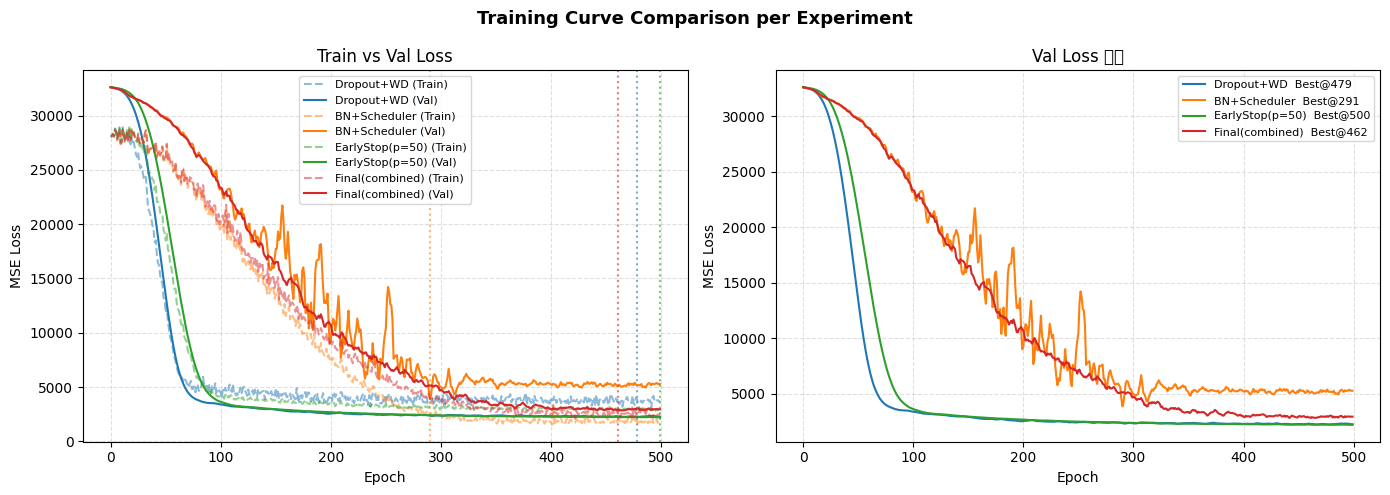


  모델                                  RMSE        R²      Δ RMSE
--------------------------------------------------------------
  Baseline (기존)                    53.9787    0.4501  +  0.0000
  Dropout+WD                       54.2408    0.4447  +  0.2621
  BN+Scheduler                     65.9413    0.1793  + 11.9626
  EarlyStop(p=50)                  53.9787    0.4501  +  0.0000
  Final (결합)                       54.2493    0.4445  +  0.2706
  * Δ RMSE: 음수(-) = 기존 대비 개선, 양수(+) = 기존 대비 악화


In [8]:
# ── 학습 곡선 비교 시각화 ─────────────────────────────────────────────────────
all_curves = {
    "Baseline": ([None], [None], 500),  # 기존 결과는 재실행하지 않으므로 표기만
    "Dropout+WD":       (tl_drop,  vl_drop,  be_drop),
    "BN+Scheduler":     (tl_bn,    vl_bn,    be_bn),
    f"EarlyStop(p=50)": (tl_es,    vl_es,    be_es),
    "Final(combined)": (tl_final, vl_final, be_final),
}
# Baseline은 곡선 데이터 없으므로 제외하고 시각화
plot_curves(
    {k: v for k, v in all_curves.items() if v[0][0] is not None},
    title="Training Curve Comparison per Experiment"
)


# ── 성능 지표 비교 표 ────────────────────────────────────────────────────────
all_metrics = [
    {"label": "Baseline (기존)",       "rmse": 53.9787, "r2": 0.4501},
    {"label": "Dropout+WD",            "rmse": metrics_drop["rmse"], "r2": metrics_drop["r2"]},
    {"label": "BN+Scheduler",          "rmse": metrics_bn["rmse"],   "r2": metrics_bn["r2"]},
    {"label": f"EarlyStop(p={PATIENCE})", "rmse": metrics_es["rmse"], "r2": metrics_es["r2"]},
    {"label": "Final (결합)",           "rmse": metrics_final["rmse"], "r2": metrics_final["r2"]},
]

print()
print("=" * 62)
print(f"  {'모델':<30}  {'RMSE':>8}  {'R²':>8}  {'Δ RMSE':>10}")
print("-" * 62)
baseline_rmse = 53.9787
for m in all_metrics:
    delta = m["rmse"] - baseline_rmse
    sign  = "+" if delta >= 0 else ""
    print(f"  {m['label']:<30}  {m['rmse']:>8.4f}  {m['r2']:>8.4f}  "
          f"{sign}{delta:>8.4f}")
print("=" * 62)
print("  * Δ RMSE: 음수(-) = 기존 대비 개선, 양수(+) = 기존 대비 악화")

### Train vs Val Loss 학습 곡선 해석

각 실험이 의도한 최적화 기법들이 실제 학습 곡선(Learning Curve)에 어떻게 반영되었는지 분석한 결과입니다.

**1. 두 선의 간격 (Gap) = 과적합 제어 여부**
* **이론적 기대 (`Dropout+WD`):** 규제 기법이 적용되어 훈련 데이터만 외우는 현상을 방지하므로, Train Loss와 Val Loss 간격이 좁아져야 합니다.
* **실제 관측:** `Dropout+WD`와 `EarlyStop` 실험의 경우 두 선의 간격이 매우 가까우며 안정적으로 수렴이 잘 되었음을 확인할 수 있습니다. 과적합이 효과적으로 제어되었습니다.

**2. 선의 매끄러움과 하락 속도 = 학습 안정화 여부**
* **이론적 기대 (`BN+Scheduler`):** 배치 정규화와 학습률 스케줄링의 조화로 곡선이 훨씬 부드럽고 가파르게 최저점을 향해 직진해야 합니다.
* **실제 관측 (예측과 불일치):** `BN+Scheduler`를 넣었을 때 오히려 선이 심하게 위아래로 요동치는 현상이 관측되었습니다. 이는 예상과 반대되는 결과로, 해당 데이터셋에서는 현재의 배치 정규화나 스케줄러 세팅이 오히려 내부 학습을 불안정하게 만들었음을 시사합니다.

**3. Val Loss의 반등(U자형) 지점 = 최적 종료 시점**
* **이론적 기대 (`EarlyStop`):** Val Loss가 더 이상 내려가지 않고 뚜렷하게 상승하는 변곡점(최적점)에서 학습이 끊어져야 합니다.
* **실제 관측:** 곡선이 뚜렷한 U자형으로 반등하기보다는 직선 형태에 가깝게 수렴하며 마무리되었습니다. 심각한 과적합 발산 현상은 없었던 것으로 보입니다.

**4. 최종 도달한 최저점의 높이 = 절대적인 성능 한계**
* **이론적 기대 (`Final`):** 모든 기법의 장점이 결합되어 가장 낮은 Val Loss(절대적 높이)를 기록해야 합니다.
* **실제 관측:** `Dropout+WD`와 `EarlyStop`은 에폭(Epoch) 100 부근에서 이미 최저점 근처에 도달했으나, `BN+Scheduler`와 모든 것을 합친 `Final(combined)` 모델은 에폭 300 근처에서야 뒤늦게 최저점에 도달했습니다. 또한 최종 모델이 개별 실험 모델의 최저점보다 뚜렷하게 더 낮은 바닥을 뚫지 못한 것으로 보아, 여러 규제 기법이 중첩되면서 오히려 과소적합(Underfitting)이나 기법 간 충돌을 유발했을 가능성이 높습니다.

---
## 6. 결론 및 한계

### 의의: 모듈화를 통한 재현성 및 기여도 추적
- 각 개선 기법의 효과를 **독립적으로 검증**한 후 결합하여, 각 기법의 기여도를 추적 가능하게 했다.
- `run_experiment()` 함수의 모듈화로 어떤 실험도 동일한 코드로 재현 가능하다.


<br>

---


### 결과 해석
* **정규화 역효과와 과소적합**:
  정규화 기법(Dropout, Weight Decay)을 추가한 실험에서 오히려 오차가 증가(성능 악화)한 것은 현재 모델이 과적합 상태가 아님을 방증한다. 모델이 데이터의 복잡성을 충분히 포착하지 못하는 **'과소적합(Underfitting)'** 상태에서 규제를 가해 학습을 인위적으로 억제했기 때문에 성능이 하락한 것으로 분석된다.

* **Early Stopping 미발동의 의미**:
  Patience를 50으로 설정했음에도 조기 종료가 발동되지 않고 500 에폭(Epoch)을 완주했다는 것은, 검증 손실(Val Loss)이 반등하는 심각한 과적합 구간에 진입하지 않았음을 뜻한다. 즉, 모델은 500 에폭 내내 매우 느리지만 지속적으로 최저점을 향해 수렴 중이었음을 시사한다.

<br>

---
### 남은 한계

| 항목 | 내용 |
|------|------|
| 표본 크기 | 테스트 세트 n≈88로 통계적 유의성 검정 불가. K-Fold CV 필요 |
| 하이퍼파라미터 탐색 | `dropout_p`, `weight_decay`, `patience` 모두 수동 설정. Optuna 등 자동화 탐색 권장 |
| 모델 비교 없음 | Ridge/Lasso/RandomForest 등 기저 모델 대비 우위를 검증하지 않음 |
| 데이터 특성 | 이미 정규화된 공식 데이터셋으로, 실제 현장 데이터에서는 전처리 단계가 추가로 필요 |